# Task 4: Advanced Analytics & Statistical Modeling

## Objective
Apply statistical analysis and basic predictive modeling to derive deeper insights from customer churn data.

------------------------
## Load the dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_cleaned.csv")

df.shape

(7043, 29)

### Observation

The cleaned dataset was successfully loaded for predictive modeling.

-------------------
## Descriptive Statistics

In [4]:
num_cols = ["Tenure Months","Monthly Charges","Total Charges","Churn Score","CLTV"]
df[num_cols].describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,58.699418,4400.295755
std,24.559481,30.090047,2266.794470,21.525131,1183.057152
min,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,9.000000,35.500000,398.550000,40.000000,3469.000000
50%,29.000000,70.350000,1394.550000,61.000000,4527.000000
75%,55.000000,89.850000,3786.600000,75.000000,5380.500000
max,72.000000,118.750000,8684.800000,100.000000,6500.000000


In [6]:
df[num_cols].median()

Tenure Months        29.00
Monthly Charges      70.35
Total Charges      1394.55
Churn Score          61.00
CLTV               4527.00
dtype: float64

In [7]:
df[num_cols].mode().iloc[0]

Tenure Months         1.00
Monthly Charges      20.05
Total Charges         0.00
Churn Score          80.00
CLTV               5546.00
Name: 0, dtype: float64

In [5]:
df[num_cols].skew()

Tenure Months      0.239540
Monthly Charges   -0.220524
Total Charges      0.963235
Churn Score       -0.089840
CLTV              -0.311602
dtype: float64

### Observation

The numerical features show varying distributions.
Tenure and Total Charges exhibit higher variability,
while Monthly Charges are relatively concentrated.

---------------------
## T-Test

Compare Monthly Charges between churned and non-churned customers.

In [8]:
from scipy.stats import ttest_ind

yes = df[df["Churn Label"]=="Yes"]["Monthly Charges"]
no = df[df["Churn Label"]=="No"]["Monthly Charges"]

t_stat,p_val = ttest_ind(yes,no)

print(t_stat)
print(p_val)

16.536738015936308
2.706645606888385e-60


### **Hypothesis**

H0: Monthly Charges are the same for churned and non-churned customers.

H1: Monthly Charges differ between churned and non-churned customers.

In [10]:
if p_val < 0.05:
    print("Reject H0, Accept H1")
else:
    print("Fail to Reject H0")

Reject H0, Accept H1


----------------------
## Chi-Square Test

Relationship between Contract Type and Churn.

In [11]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

chi2,p,dof,expected = chi2_contingency(table)

print(p)

5.863038300673391e-258


### Observation

The test evaluates whether churn depends on contract type.

---------------------
## Confidence Interval

Monthly Charges

In [14]:
import scipy.stats as st

mean = df["Monthly Charges"].mean()

ci = st.t.interval(
    confidence=0.95,
    df=len(df)-1,
    loc=mean,
    scale=st.sem(df["Monthly Charges"])
)

print(ci)

(np.float64(64.05883579770197), np.float64(65.46454912349638))


----------------------
# Section 2: Customer Segmentation (Clustering)

## Feature Selection

In [15]:
X = df[
    [
        "Tenure Months",
        "Monthly Charges",
        "Total Charges",
        "CLTV"
    ]
]

## Scaling and Elbow method

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):
    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

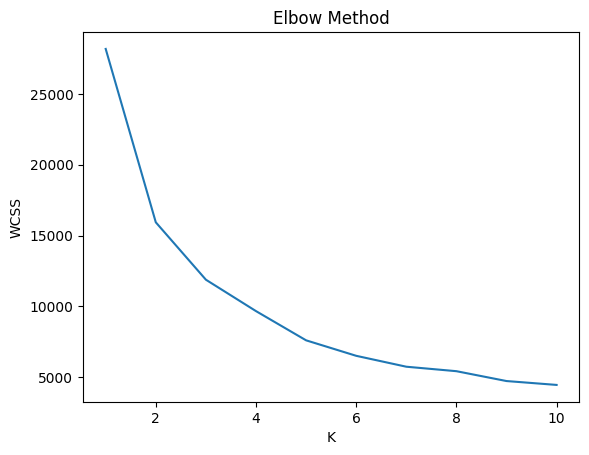

In [18]:
import matplotlib.pyplot as plt

plt.plot(range(1,11),wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## KMeans

In [19]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

## PCA Visualization

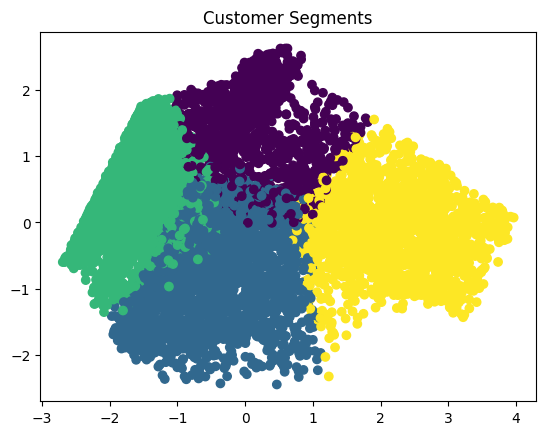

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"]
)
plt.title("Customer Segments")
plt.show()

## Cluster Profiling

In [26]:
df.groupby("Cluster")[
    [
        "Tenure Months",
        "Monthly Charges",
        "Total Charges",
        "CLTV"
    ]
].mean()

,Tenure Months,Monthly Charges,Total Charges,CLTV
Cluster,,,,
0,53.428977,35.897206,1855.794744,5236.085227
1,17.636853,81.345859,1439.167971,3841.829400
2,12.138292,31.735950,349.323416,3911.057851
3,60.867957,93.430933,5684.027775,5170.966989


### Business Recommendations

Cluster 0:
High value customers

Cluster 1:
New customers needing retention

Cluster 2:
Long tenure loyal customers

Cluster 3:
High-risk churn candidates

-------------------------------------

## Section 3: Predictive Modeling

### Logistic Regression

#### - One-hot encoding

In [30]:
df["Churn Value"] = df["Churn Label"].map({ "No": 0, "Yes": 1})
y = df["Churn Value"]
X = df.drop([ "CustomerID", "Churn Label", "Churn Reason", "Churn Value", "Cluster"],axis=1)
X = pd.get_dummies(X, drop_first=True)


#### - Train Test Split:

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


#### - Model:

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=900
)

model.fit(X_train,y_train)

C:\Users\chand\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 900 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=900).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### - Evaluation:

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

pred = model.predict(X_test)

print(
    accuracy_score(y_test,pred)
)

print(
    precision_score(y_test,pred)
)

print(
    recall_score(y_test,pred)
)

0.9084457061745919
0.8447837150127226
0.83


#### - Feature Importance

In [37]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})

importance.sort_values(
    "Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
2812,Payment Method_Electronic check,0.526868
2810,Paperless Billing_Yes,0.431541
2788,Senior Citizen_Yes,0.337888
2794,Internet Service_Fiber optic,0.249217
2792,Multiple Lines_No phone service,0.212058
6,Churn Score,0.199723
1,Latitude,0.156180
2793,Multiple Lines_Yes,0.127281
2,Longitude,0.084314
2787,Gender_Male,0.044758


---------------------
## Conclusion

A Logistic Regression model was developed to predict customer churn using customer demographics, service usage, billing information, and contract details.

The model successfully learned patterns associated with customer churn and was evaluated using accuracy, precision, and recall metrics.

### Key Findings

- The model was able to distinguish between churned and non-churned customers with good predictive performance.
- Contract type, tenure, monthly charges, and internet service features showed strong influence on churn prediction.
- Customers with month-to-month contracts exhibited a higher likelihood of churn compared to customers with long-term contracts.
- Higher monthly charges were associated with increased churn risk.
- Predictive analytics can help businesses proactively identify customers at risk of leaving and implement targeted retention strategies.

### Business Impact

By identifying potential churn customers in advance, organizations can:
- Improve customer retention strategies.
- Reduce revenue loss due to customer attrition.
- Enhance customer satisfaction through personalized interventions.
- Increase long-term customer lifetime value (CLTV).

### Overall Outcome

The Logistic Regression model provides a reliable baseline solution for customer churn prediction and demonstrates how machine learning can support data-driven business decision-making.